# 🔮 Fase 5: Predicción de Vida Útil Remanente (LSTM)

Con los sensores seleccionados del C-MAPSS FD001, vamos a entrenar una **Red Neuronal Recurrente (LSTM)**. Las LSTMs tienen "memoria" y son ideales para predecir el RUL basándose en la secuencia histórica (ventana de tiempo) del comportamiento del motor.

### Mejoras respecto a la versión anterior
- Learning rate más alto (0.005) con **ReduceLROnPlateau** scheduler
- **100 epochs** en lugar de 20 (el modelo se estancaba y necesitaba más tiempo)
- **Evaluación completa sobre el set de test** (`test_FD001.txt` + `RUL_FD001.txt`)
- Gráfico de RUL predicho vs real para un motor de ejemplo

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import joblib

plt.style.use('dark_background')
device = torch.device('cpu')
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 1. Carga de Datos y Preprocesamiento

In [ ]:
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv('../data/cmapss/train_FD001.txt', sep='\s+', header=None, names=columns)
test_df = pd.read_csv('../data/cmapss/test_FD001.txt', sep='\s+', header=None, names=columns)
truth_df = pd.read_csv('../data/cmapss/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])

# RUL para train (run-to-failure)
max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)
train_df = train_df.merge(max_cycles, on=['unit_nr'], how='left')
train_df['RUL'] = (train_df['max_cycle'] - train_df['time_cycles']).clip(upper=125)

# Sensores útiles (del notebook 04)
try:
    useful_sensors = joblib.load('../models/useful_sensors_cmapss.pkl')
except:
    useful_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11',
                      'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

print(f"Usando {len(useful_sensors)} sensores.")

# Normalizamos con MinMaxScaler (fit solo en train, transform en ambos)
scaler = MinMaxScaler()
train_df[useful_sensors] = scaler.fit_transform(train_df[useful_sensors])
test_df[useful_sensors] = scaler.transform(test_df[useful_sensors])
joblib.dump(scaler, '../models/scalers/lstm_scaler.pkl')

print(f"Train: {train_df.shape[0]} registros, {train_df['unit_nr'].nunique()} motores")
print(f"Test:  {test_df.shape[0]} registros, {test_df['unit_nr'].nunique()} motores")

Usando 12 sensores.
Train: 20631 registros, 100 motores
Test:  13096 registros, 100 motores


## 2. Ventanas Deslizantes (Sliding Windows)

In [ ]:
SEQUENCE_LENGTH = 30

def create_sequences(df, seq_length, cols):
    X, y = [], []
    for unit_id in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit_id]
        data_matrix = unit_data[cols].values
        label_array = unit_data['RUL'].values
        
        for i in range(len(unit_data) - seq_length):
            X.append(data_matrix[i:i+seq_length])
            y.append(label_array[i+seq_length])
            
    return np.array(X), np.array(y)

def create_test_sequences(df, seq_length, cols):
    """Para test, tomamos solo la ULTIMA ventana de cada motor."""
    X = []
    for unit_id in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit_id]
        data_matrix = unit_data[cols].values
        if len(data_matrix) >= seq_length:
            X.append(data_matrix[-seq_length:])
        else:
            # Pad con ceros si la secuencia es mas corta
            pad = np.zeros((seq_length - len(data_matrix), len(cols)))
            X.append(np.vstack([pad, data_matrix]))
    return np.array(X)

X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH, useful_sensors)
X_test = create_test_sequences(test_df, SEQUENCE_LENGTH, useful_sensors)
y_test = truth_df['RUL'].values.clip(max=125)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1,1))
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

X_train: (17631, 30, 12) | y_train: (17631,)
X_test:  (100, 30, 12)  | y_test:  (100,)


## 3. Arquitectura LSTM

In [ ]:
class RULPredictorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super(RULPredictorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = RULPredictorLSTM(input_dim=len(useful_sensors)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

print(f"Parametros totales: {sum(p.numel() for p in model.parameters()):,}")

Parametros totales: 55,361


c:\Users\agust\Proyectos\ypf-predictive-maintenance\venv\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


## 4. Entrenamiento (100 epochs con LR Scheduler)

Epoch [10/100] - MSE: 212.78 - RMSE: 14.59 - LR: 0.005000
Epoch [20/100] - MSE: 203.87 - RMSE: 14.28 - LR: 0.005000
Epoch [30/100] - MSE: 197.88 - RMSE: 14.07 - LR: 0.005000
Epoch [40/100] - MSE: 193.18 - RMSE: 13.90 - LR: 0.005000
Epoch [50/100] - MSE: 182.14 - RMSE: 13.50 - LR: 0.005000
Epoch [60/100] - MSE: 174.41 - RMSE: 13.21 - LR: 0.005000
Epoch [70/100] - MSE: 171.70 - RMSE: 13.10 - LR: 0.005000
Epoch [80/100] - MSE: 145.75 - RMSE: 12.07 - LR: 0.005000
Epoch [90/100] - MSE: 102.06 - RMSE: 10.10 - LR: 0.005000
Epoch [100/100] - MSE: 71.37 - RMSE: 8.45 - LR: 0.005000


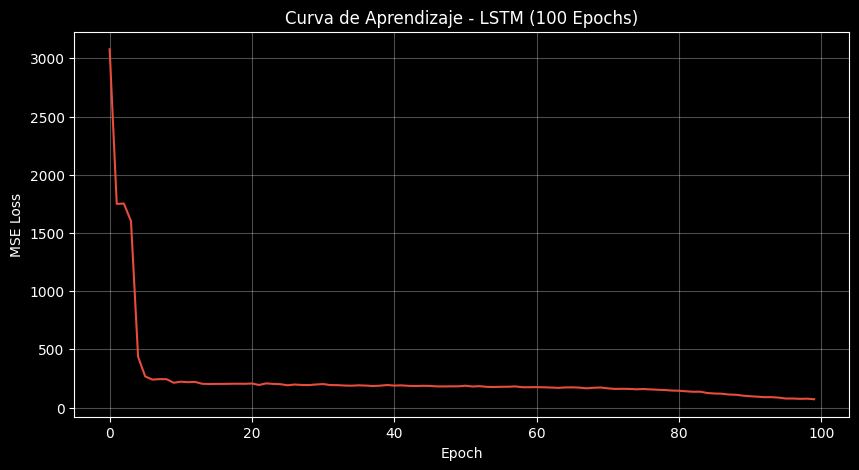


Mejor Loss de entrenamiento: 71.37 (RMSE: 8.45 ciclos)


In [ ]:
epochs = 100
train_losses = []
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    
    # Guardar el mejor modelo
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), '../models/lstm_rul_best.pt')
    
    if (epoch+1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] - MSE: {avg_loss:.2f} - RMSE: {np.sqrt(avg_loss):.2f} - LR: {current_lr:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, color='#e74c3c', linewidth=1.5)
plt.title('Curva de Aprendizaje - LSTM (100 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()

print(f"\nMejor Loss de entrenamiento: {best_loss:.2f} (RMSE: {np.sqrt(best_loss):.2f} ciclos)")

## 5. Evaluacion en Set de Test
Cargamos el mejor modelo guardado y evaluamos sobre los 100 motores del set de test, comparando contra el RUL real (`RUL_FD001.txt`).

In [ ]:
# Cargar el mejor modelo
model.load_state_dict(torch.load('../models/lstm_rul_best.pt', weights_only=True))
model.eval()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test)
    y_pred = model(X_test_tensor).numpy().flatten()

# Metricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('=' * 40)
print('RESULTADOS SOBRE SET DE TEST (100 motores)')
print('=' * 40)
print(f'RMSE: {rmse:.2f} ciclos')
print(f'MAE:  {mae:.2f} ciclos')
print(f'\nReferencia literatura: RMSE ~12-13 ciclos (modelos LSTM tuneados con hiperparametros)')

RESULTADOS SOBRE SET DE TEST (100 motores)
RMSE: 18.25 ciclos
MAE:  13.67 ciclos

Referencia literatura: RMSE ~12-13 ciclos (modelos LSTM tuneados con hiperparametros)


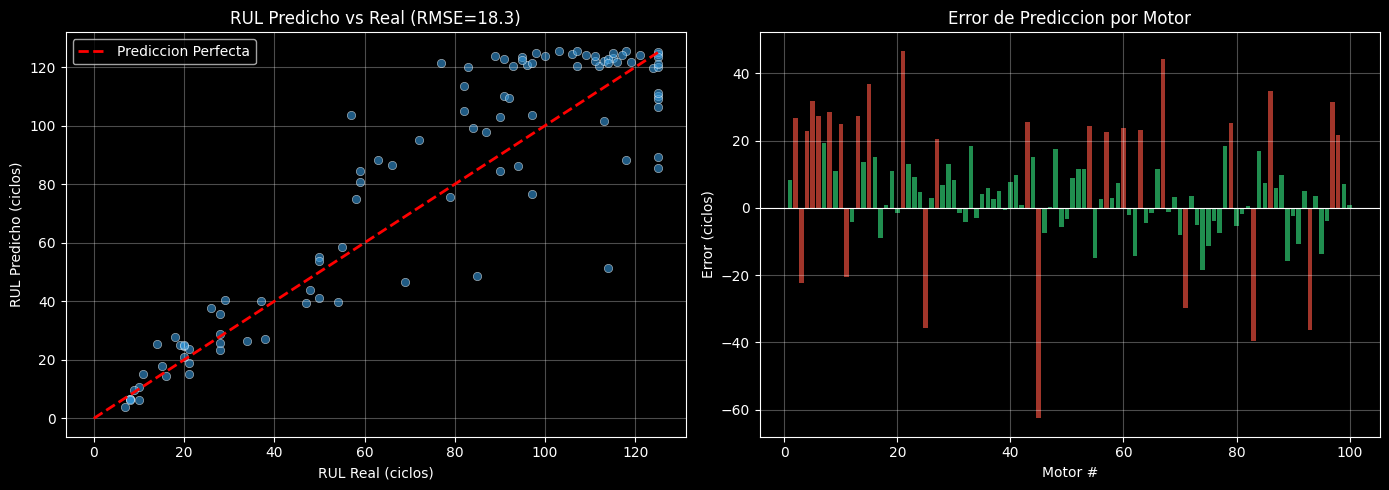

Predicciones dentro de +/-10 ciclos: 51.0%
Predicciones dentro de +/-20 ciclos: 73.0%


In [ ]:
# Grafico: RUL Predicho vs RUL Real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#3498db', edgecolors='white', linewidth=0.5)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=2, label='Prediccion Perfecta')
axes[0].set_xlabel('RUL Real (ciclos)')
axes[0].set_ylabel('RUL Predicho (ciclos)')
axes[0].set_title(f'RUL Predicho vs Real (RMSE={rmse:.1f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Error por motor
errors = y_pred - y_test
colors = ['#e74c3c' if abs(e) > 20 else '#2ecc71' for e in errors]
axes[1].bar(range(1, len(errors)+1), errors, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='white', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Motor #')
axes[1].set_ylabel('Error (ciclos)')
axes[1].set_title('Error de Prediccion por Motor')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadisticas del error
within_10 = np.sum(np.abs(errors) <= 10) / len(errors) * 100
within_20 = np.sum(np.abs(errors) <= 20) / len(errors) * 100
print(f'Predicciones dentro de +/-10 ciclos: {within_10:.1f}%')
print(f'Predicciones dentro de +/-20 ciclos: {within_20:.1f}%')

In [ ]:
# Guardamos el modelo final (copiamos el mejor)
torch.save(model.state_dict(), '../models/lstm_rul.pt')
print('Modelo LSTM final exportado exitosamente a models/lstm_rul.pt')

Modelo LSTM final exportado exitosamente a models/lstm_rul.pt
